# Clasificación de *Helicobacter pylori* mediante Redes Neuronales y Datos de Microbiota Gástrica

**Universidad Nacional de Colombia**

---

Este proyecto evalúa la eficacia de modelos de aprendizaje automático no lineales (redes neuronales multicapa) para clasificar la infección por *Helicobacter pylori* a partir de datos de microbiota gástrica humana obtenidos mediante secuenciación 16S rRNA.

**Motivación clínica:** El cáncer gástrico es una de las principales causas de mortalidad mundial. La infección por *H. pylori* es su factor de riesgo más determinante, causando disbiosis (reorganización del ecosistema microbiano). Los métodos estadísticos tradicionales frecuentemente no capturan las interacciones **no lineales** presentes en estos sistemas ecológicos complejos.

**Datos:** 29 pacientes (Klymiuk et al., 2017), abundancias a nivel de género transformadas con CLR (*Centered Log-Ratio*).

---

## 1. Library Imports

Se cargan las librerías necesarias para el análisis: manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`), aprendizaje automático (`scikit-learn`) y el framework para la red neuronal (`tensorflow/keras`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Data Loading and Preparation

En esta fase del proyecto, se cargan y procesan dos variantes del dataset de abundancia taxonómica para evaluar la robustez del modelo de Redes Neuronales (MLP) bajo diferentes escenarios biológicos:
### 2.1. Variantes del Dataset

Para un análisis comparativo, se utilizaron dos archivos de entrada:

    Dataset Completo (-hp.csv): Incluye todas las abundancias taxonómicas, incluida la de Helicobacter. Se utiliza como Línea Base (Baseline) para medir la capacidad de diagnóstico directo.

    Dataset sin Helicobacter (-nhp.csv): Se remueve intencionalmente la columna del patógeno dominante.

### 2.2. Transformación y Preprocesamiento

Ambos archivos integran la transformación CLR (Centered Log-Ratio). Esta técnica es fundamental en el análisis de microbioma para:

    Corregir la naturaleza composicional de los datos (donde las abundancias son relativas y suman 1 o 100%).

    Evitar correlaciones artificiales y sesgos estadísticos.

    Normalizar las distribuciones para que la Red Neuronal converja más rápido.

### 2.3. Integración de Metadatos y Clasificación

Se realiza un proceso de merge (unión) con el archivo de metadatos (sample_metadata_binary) utilizando el identificador único Sample_ID. Esto permite asociar cada perfil bacteriano con su etiqueta real:

    1 (H.p.+): Paciente con infección confirmada.

    0 (H.p.-): Paciente sano o control.

In [2]:
data_nhp   = pd.read_csv('/content/otu_genus_clr_prevfiltered-nhp.csv')
binary_nhp = pd.read_csv('/content/sample_metadata_binary-nhp.csv')

In [3]:
data  = pd.read_csv('/content/otu_genus_clr_prevfiltered-hp.csv')
binary = pd.read_csv('/content/sample_metadata_binary-hp.csv')

In [4]:
data.head()

,Sample_ID,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,...,Staphylococcus,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella]
0,P001Z12,1.136165,5.666962,-1.329606,5.125296,3.407573,2.507664,5.543468,3.427601,-1.329606,...,2.675229,3.262707,7.029766,-1.329606,-1.329606,2.243472,-1.329606,6.580870,6.379528,5.467354
1,P001Z13,-0.348473,6.435700,0.393300,2.158804,3.982938,-1.146599,2.089231,4.501488,3.738455,...,0.896899,0.814463,7.661200,-0.348473,3.209424,-0.105595,2.686182,6.275081,6.072512,4.416165
2,P001Z14,1.367808,5.945386,0.072880,3.663450,3.124310,-1.512935,4.293321,3.337950,3.367871,...,-1.512935,2.748320,7.190134,-1.512935,2.652594,-1.512935,1.913662,5.645632,6.106997,5.556124
3,P001Z18,4.143998,5.634243,2.947621,3.197061,2.785120,-0.737450,3.665411,2.930816,2.287356,...,-1.140968,2.203289,7.952309,-1.140968,2.626075,-1.140968,1.656895,6.257157,6.162395,4.278155
4,P002Z18,2.350095,3.820098,-1.238502,6.664077,-1.238502,2.943589,6.037687,-1.238502,-1.238502,...,3.483684,5.517361,6.830796,-1.238502,-1.238502,-1.238502,-1.238502,7.214300,3.880349,-1.238502


In [5]:
binary.head()

,Sample_ID,Hp_Status_binary,label_binary,Hp_CagA_Status,Score
0,P001Z12,H.p.-,0,H.p.-,not aplicable
1,P001Z13,H.p.-,0,H.p.-,not aplicable
2,P001Z14,H.p.-,0,H.p.-,not aplicable
3,P001Z18,H.p.-,0,H.p.-,not aplicable
4,P002Z18,H.p.-,0,H.p.-,not aplicable


In [6]:

df = pd.merge(data, binary[['Sample_ID', 'label_binary']], on='Sample_ID')
df_nhp = pd.merge(data_nhp, binary_nhp[['Sample_ID', 'label_binary']], on='Sample_ID')

print(f"Dimensiones del dataset: {df.shape}")
print(f"Muestras : {len(df)}")
print(f"Taxones  : {df.shape[1] - 2}  (sin Sample_ID y label_binary)")
print(f"\nDistribución de clases:")
print(df['label_binary'].value_counts().rename({0: 'H.p.- (No infectado)', 1: 'H.p.+ (Infectado)'}))

X = df.drop(['Sample_ID', 'label_binary'], axis=1).values
y = df['label_binary'].values

df.head()

Dimensiones del dataset: (29, 62)
Muestras : 29
Taxones  : 60  (sin Sample_ID y label_binary)

Distribución de clases:
label_binary
H.p.+ (Infectado)       20
H.p.- (No infectado)     9
Name: count, dtype: int64


,Sample_ID,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,...,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella],label_binary
0,P001Z12,1.136165,5.666962,-1.329606,5.125296,3.407573,2.507664,5.543468,3.427601,-1.329606,...,3.262707,7.029766,-1.329606,-1.329606,2.243472,-1.329606,6.580870,6.379528,5.467354,0
1,P001Z13,-0.348473,6.435700,0.393300,2.158804,3.982938,-1.146599,2.089231,4.501488,3.738455,...,0.814463,7.661200,-0.348473,3.209424,-0.105595,2.686182,6.275081,6.072512,4.416165,0
2,P001Z14,1.367808,5.945386,0.072880,3.663450,3.124310,-1.512935,4.293321,3.337950,3.367871,...,2.748320,7.190134,-1.512935,2.652594,-1.512935,1.913662,5.645632,6.106997,5.556124,0
3,P001Z18,4.143998,5.634243,2.947621,3.197061,2.785120,-0.737450,3.665411,2.930816,2.287356,...,2.203289,7.952309,-1.140968,2.626075,-1.140968,1.656895,6.257157,6.162395,4.278155,0
4,P002Z18,2.350095,3.820098,-1.238502,6.664077,-1.238502,2.943589,6.037687,-1.238502,-1.238502,...,5.517361,6.830796,-1.238502,-1.238502,-1.238502,-1.238502,7.214300,3.880349,-1.238502,0


## 3. Validation Strategy, Pre-processing and Baseline MLP

**Validación — LOOCV:** Dado el tamaño reducido (n=29), se implementa *Leave-One-Out Cross-Validation*: en cada iteración una sola muestra actúa como test y las n-1 restantes como entrenamiento, repitiéndose 29 veces. Es mejor para muestras con pocos datos garantizando una evaluación exhaustiva sin desperdiciar datos.

**Pre-processing anti-leakage (Walsh et al., 2024):** El filtro de varianza (`VarianceThreshold`, umbral=0.1) y el escalado (`StandardScaler`) se aplican **dentro del loop**, ajustándose únicamente con los datos de entrenamiento de cada fold. Hacerlo fuera produciría *data leakage* e inflaría artificialmente las métricas.

**Arquitectura baseline MLP:**
```
Input → Dense(16, ReLU) → Dropout(0.3) → Dense(1, Sigmoid)
```
Simple y superficial para minimizar el riesgo de sobreajuste con n=29.

In [17]:
loo = LeaveOneOut()
y_true, y_pred, y_probs = [], [], []

print(f"Iniciando LOOCV — n={len(X)} muestras")
print("-" * 45)

for i, (train_idx, test_idx) in enumerate(loo.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Pre-processing (dentro del loop → anti-leakage)
    sel  = VarianceThreshold(threshold=0.1)
    Xtr  = sel.fit_transform(X_train); Xte = sel.transform(X_test)
    sc   = StandardScaler()
    Xtr  = sc.fit_transform(Xtr);      Xte = sc.transform(Xte)

    # Modelo baseline
    model = models.Sequential([
      layers.Input(shape=(Xtr.shape[1],)), # Se define la entrada aquí de forma limpia
      layers.Dense(16, activation='relu'),
      layers.Dropout(0.3),
      layers.Dense(1, activation='sigmoid')
  ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.fit(Xtr, y_train, epochs=60, batch_size=4, verbose=0)

    prob = model.predict(Xte, verbose=0)[0][0]
    y_probs.append(prob)
    y_pred.append(1 if prob > 0.5 else 0)
    y_true.append(y_test[0])

    if (i + 1) % 5 == 0 or (i + 1) == len(X):
        print(f"  Fold {i+1:2d}/{len(X)} — prob={prob:.3f}  pred={y_pred[-1]}  true={y_true[-1]}")

print("-" * 45)
print("LOOCV finalizado.")

Iniciando LOOCV — n=29 muestras
---------------------------------------------
  Fold  5/29 — prob=0.919  pred=1  true=0
  Fold 10/29 — prob=0.846  pred=1  true=0
  Fold 15/29 — prob=0.990  pred=1  true=1
  Fold 20/29 — prob=0.533  pred=1  true=1
  Fold 25/29 — prob=0.864  pred=1  true=1
  Fold 29/29 — prob=0.908  pred=1  true=1
---------------------------------------------
LOOCV finalizado.


## 4. Baseline Results and Performance Evaluation

Se calculan métricas robustas priorizando **F1-Score** y **AUC-ROC** sobre el accuracy simple, ya que proporcionan una mejor visión del poder predictivo real en sistemas biológicos con posible desbalance de clases. La Matriz de Confusión visualiza los aciertos y errores en la clasificación.

> Los Falsos Negativos (infectados clasificados como sanos) son especialmente críticos ya que pdrian retrasar un tratamiento preventivo.


  RESULTADOS BASELINE — MLP [16] — nhp
  F1-Score : 0.9231
  AUC-ROC  : 0.9278
  Accuracy : 0.8966


/tmp/ipykernel_11748/800273472.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


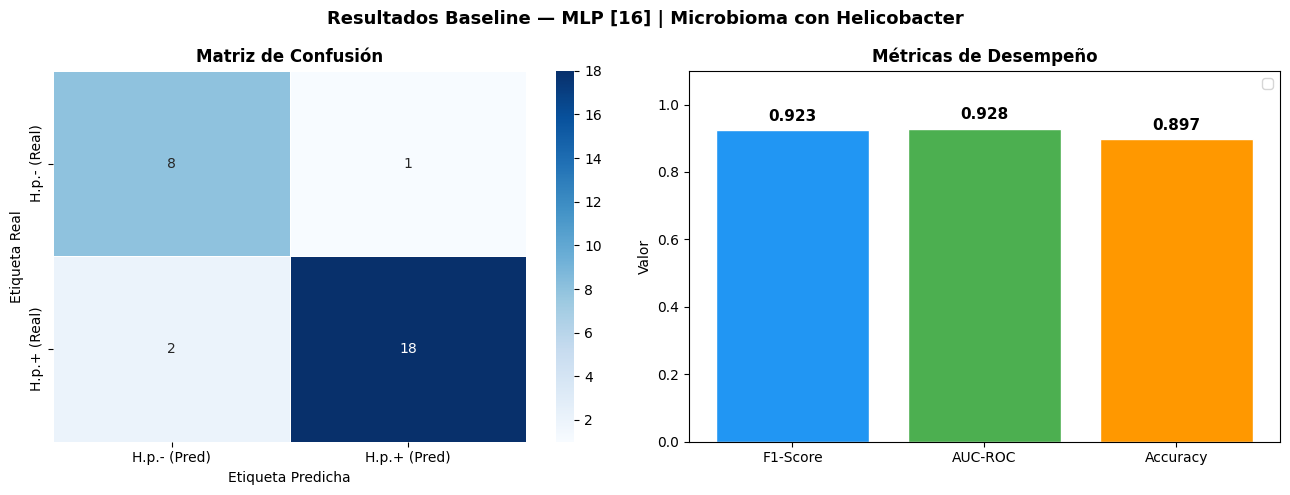


VN=8  FP=1  FN=2   VP=18


In [12]:
f1  = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_probs)
acc = accuracy_score(y_true, y_pred)
cm  = confusion_matrix(y_true, y_pred)

print("\n" + "="*45)
print("  RESULTADOS BASELINE — MLP [16] — nhp")
print("="*45)
print(f"  F1-Score : {f1:.4f}")
print(f"  AUC-ROC  : {auc:.4f}")
print(f"  Accuracy : {acc:.4f}")
print("="*45)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Resultados Baseline — MLP [16] | Microbioma con Helicobacter', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['H.p.- (Pred)', 'H.p.+ (Pred)'],
            yticklabels=['H.p.- (Real)', 'H.p.+ (Real)'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].set_ylabel('Etiqueta Real')
axes[0].set_xlabel('Etiqueta Predicha')

colores = ['#2196F3', '#4CAF50', '#FF9800']
barras  = axes[1].bar(['F1-Score', 'AUC-ROC', 'Accuracy'], [f1, auc, acc], color=colores, edgecolor='white')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Valor')
axes[1].set_title('Métricas de Desempeño', fontweight='bold')
axes[1].legend()
for b, v in zip(barras, [f1, auc, acc]):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f'{v:.3f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nVN={tn}  FP={fp}  FN={fn}   VP={tp}")

## 5. Architecture Comparison (Depth & Width)

Se realiza un barrido sistemático de arquitecturas ejecutando un LOOCV completo por cada configuración. Cada arquitectura se define como una lista donde cada número indica las neuronas de esa capa oculta:

| Notación | Descripción |
|:---|:---|
| `[16]` | Baseline — 1 capa, 16 neuronas |
| `[24]` | Más ancha |
| `[32]` | Aún más ancha |

In [11]:
ARQUITECTURAS = [[16], [24], [32]]
resultados_arq = []

X = df_nhp.drop(['Sample_ID', 'label_binary'], axis=1).values
y = df_nhp['label_binary'].values

for arq in ARQUITECTURAS:
    nombre = str(arq)
    print(f"\nProbando Arquitectura {nombre} (Dataset: SIN HP)")
    yt, yp, ypr = [], [], []

    for train_idx, test_idx in LeaveOneOut().split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Preprocesamiento Anti-Leakage
        sel = VarianceThreshold(threshold=0.1)
        Xtr = sel.fit_transform(X_train); Xte = sel.transform(X_test)
        sc = StandardScaler()
        Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)

        # Construcción del modelo
        m = models.Sequential()
        m.add(layers.Input(shape=(Xtr.shape[1],)))
        for n in arq:
            m.add(layers.Dense(n, activation='relu'))
            m.add(layers.Dropout(0.3))

        m.add(layers.Dense(1, activation='sigmoid'))
        m.compile(optimizer='adam', loss='binary_crossentropy')
        m.fit(Xtr, y_train, epochs=60, batch_size=4, verbose=0)

        prob = m.predict(Xte, verbose=0)[0][0]
        ypr.append(prob); yp.append(1 if prob > 0.5 else 0); yt.append(y_test[0])

    # Cálculo de métricas
    f1_  = f1_score(yt, yp)
    auc_ = roc_auc_score(yt, ypr)
    acc_ = accuracy_score(yt, yp)
    resultados_arq.append({'Arquitectura': nombre, 'F1-Score': f1_, 'AUC-ROC': auc_, 'Accuracy': acc_})
    print(f"   F1={f1_:.4f}  AUC={auc_:.4f}  Acc={acc_:.4f}")

# Mostrar tabla final
df_res = pd.DataFrame(resultados_arq).sort_values('F1-Score', ascending=False)
print("\n" + "="*55)
print("  TABLA FINAL — DATASET SIN HELICOBACTER")
print("="*55)
print(df_res.to_string(index=False))


Probando Arquitectura [16] (Dataset: SIN HP)
   F1=0.6667  AUC=0.3333  Acc=0.5517

Probando Arquitectura [24] (Dataset: SIN HP)
   F1=0.6977  AUC=0.3833  Acc=0.5517

Probando Arquitectura [32] (Dataset: SIN HP)
   F1=0.7000  AUC=0.4222  Acc=0.5862

  TABLA FINAL — DATASET SIN HELICOBACTER
Arquitectura  F1-Score  AUC-ROC  Accuracy
        [32]  0.700000 0.422222  0.586207
        [24]  0.697674 0.383333  0.551724
        [16]  0.666667 0.333333  0.551724


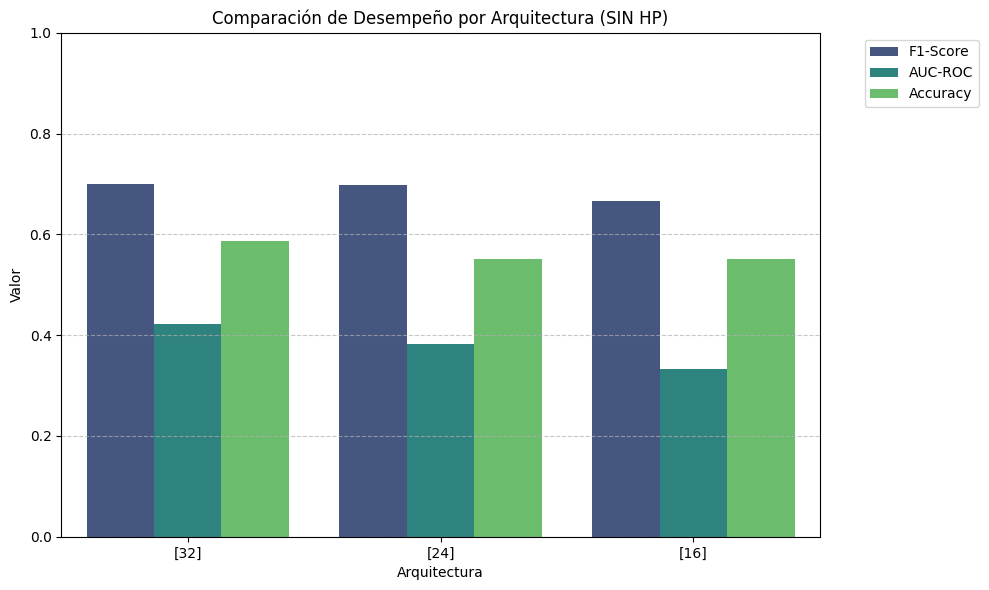

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. GRÁFICA DE BARRAS: COMPARACIÓN DE MÉTRICAS
plt.figure(figsize=(10, 6))
df_res_plot = df_res.melt(id_vars='Arquitectura', var_name='Métrica', value_name='Valor')
sns.barplot(data=df_res_plot, x='Arquitectura', y='Valor', hue='Métrica', palette='viridis')
plt.title('Comparación de Desempeño por Arquitectura (SIN HP)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Sensitivity: Activation Functions & Epochs

Se compara el efecto de dos hiperparámetros sobre la arquitectura:

- **Función de activación:** define cómo cada neurona transforma su entrada.
  - `relu` — estándar, rápida, evita el gradiente desvaneciente en redes superficiales.
  - `tanh` — salida centrada en 0, útil con distribuciones simétricas.
  - `elu` — variante suavizada de ReLU, puede converger más rápido.
- **Épocas:** controlan el tiempo de aprendizaje por fold. Pocas épocas → subajuste; muchas → riesgo de sobreajuste.


In [18]:
FUNCIONES_ACTIVACION = ['relu', 'tanh', 'elu']
LISTA_EPOCAS         = [30, 60, 90]

resultados_hp = []
total = len(FUNCIONES_ACTIVACION) * len(LISTA_EPOCAS)
contador = 0


for activacion in FUNCIONES_ACTIVACION:
    for epocas in LISTA_EPOCAS:
        contador += 1
        etiq = f"act={activacion}, epochs={epocas}"
        print(f"[{contador}/{total}]  {etiq}")
        yt, yp, ypr = [], [], []

        for train_idx, test_idx in LeaveOneOut().split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            sel = VarianceThreshold(threshold=0.1)
            Xtr = sel.fit_transform(X_train); Xte = sel.transform(X_test)
            sc  = StandardScaler()
            Xtr = sc.fit_transform(Xtr);      Xte = sc.transform(Xte)

            m = models.Sequential([
                layers.Input(shape=(Xtr.shape[1],)), # Forma correcta de definir la entrada
                layers.Dense(16, activation=activacion),
                layers.Dropout(0.3),
                layers.Dense(1, activation='sigmoid')
                ])
            m.compile(optimizer='adam', loss='binary_crossentropy')
            m.fit(Xtr, y_train, epochs=epocas, batch_size=4, verbose=0)

            prob = m.predict(Xte, verbose=0)[0][0]
            ypr.append(prob); yp.append(1 if prob > 0.5 else 0); yt.append(y_test[0])

        f1_  = f1_score(yt, yp)
        auc_ = roc_auc_score(yt, ypr)
        acc_ = accuracy_score(yt, yp)
        resultados_hp.append({'Configuración': etiq, 'Activación': activacion, 'Épocas': epocas,
                               'F1-Score': f1_, 'AUC-ROC': auc_, 'Accuracy': acc_})
        print(f"   F1={f1_:.4f}  AUC={auc_:.4f}  Acc={acc_:.4f}")

df_hp = pd.DataFrame(resultados_hp).sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_hp.index += 1
print("\n" + "="*65)
print("  TABLA — ACTIVACIÓN & ÉPOCAS (ordenado por F1-Score)")
print("="*65)
print(df_hp[['Configuración', 'Activación', 'Épocas', 'F1-Score', 'AUC-ROC', 'Accuracy']].to_string())
print(f"\nMejor configuración: {df_hp.iloc[0]['Configuración']}")
print("\nPromedio F1 por función de activación:")
print(df_hp.groupby('Activación')['F1-Score'].mean().sort_values(ascending=False).to_string())

[1/9]  act=relu, epochs=30
   F1=0.7568  AUC=0.7056  Acc=0.6897
[2/9]  act=relu, epochs=60
   F1=0.5854  AUC=0.4444  Acc=0.4138
[3/9]  act=relu, epochs=90
   F1=0.7143  AUC=0.4500  Acc=0.5862
[4/9]  act=tanh, epochs=30
   F1=0.6486  AUC=0.5889  Acc=0.5517
[5/9]  act=tanh, epochs=60
   F1=0.5946  AUC=0.5222  Acc=0.4828
[6/9]  act=tanh, epochs=90
   F1=0.6842  AUC=0.6111  Acc=0.5862
[7/9]  act=elu, epochs=30
   F1=0.5556  AUC=0.4167  Acc=0.4483
[8/9]  act=elu, epochs=60
   F1=0.6842  AUC=0.6056  Acc=0.5862
[9/9]  act=elu, epochs=90
   F1=0.6842  AUC=0.5056  Acc=0.5862

  TABLA — ACTIVACIÓN & ÉPOCAS (ordenado por F1-Score)
         Configuración Activación  Épocas  F1-Score   AUC-ROC  Accuracy
1  act=relu, epochs=30       relu      30  0.756757  0.705556  0.689655
2  act=relu, epochs=90       relu      90  0.714286  0.450000  0.586207
3   act=elu, epochs=90        elu      90  0.684211  0.505556  0.586207
4   act=elu, epochs=60        elu      60  0.684211  0.605556  0.586207
5  act=tanh,

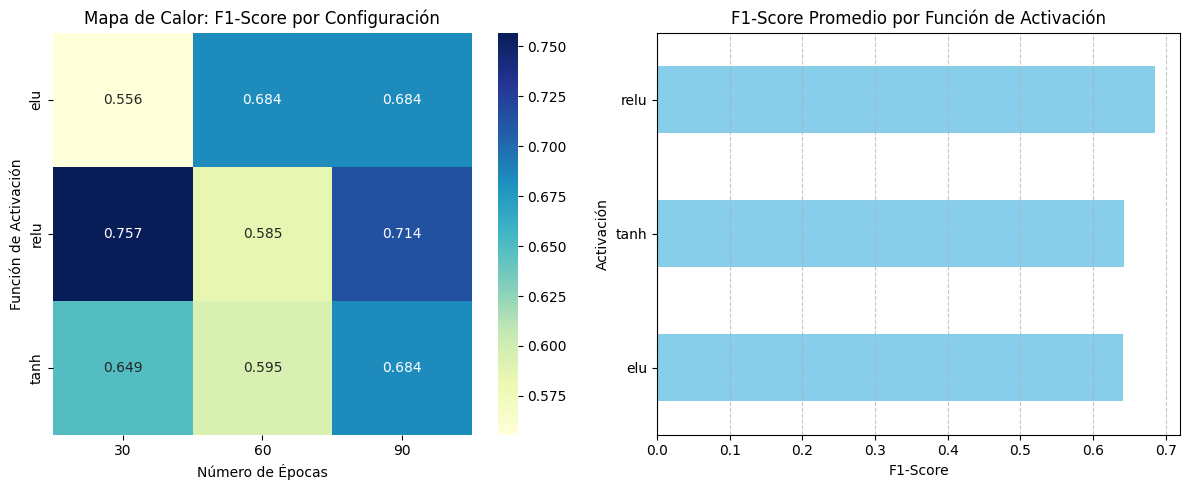

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar datos para el Heatmap (Épocas vs Activación)
pivot_f1 = df_hp.pivot(index='Activación', columns='Épocas', values='F1-Score')

plt.figure(figsize=(12, 5))

# --- GRÁFICA A: Heatmap de F1-Score ---
plt.subplot(1, 2, 1)
sns.heatmap(pivot_f1, annot=True, cmap='YlGnBu', fmt=".3f")
plt.title('Mapa de Calor: F1-Score por Configuración')
plt.ylabel('Función de Activación')
plt.xlabel('Número de Épocas')

# --- GRÁFICA B: Promedio por Activación ---
plt.subplot(1, 2, 2)
avg_f1 = df_hp.groupby('Activación')['F1-Score'].mean().sort_values()
avg_f1.plot(kind='barh', color='skyblue')
plt.title('F1-Score Promedio por Función de Activación')
plt.xlabel('F1-Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()